In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.path import Path
import matplotlib.patches as mpatches
from shapely.geometry import LineString
from shapely.ops import split
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyfonts import load_google_font

# Data

In [2]:
# Load data
data = pd.read_csv("data.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   State     48 non-null     object
 1   Category  48 non-null     object
dtypes: object(2)
memory usage: 900.0+ bytes


In [4]:
# Filter out Oklahoma and New York
data_filtered = data[~data["State"].isin(["OK", "NY"])]
# Add new rows for splitted Oklahoma and New York
new_rows = pd.DataFrame([["OK1", "Less than 1"], ["OK2", np.nan], ["NY1", "1-4"], ["NY2", np.nan]], columns=data.columns)
# Concatenate new rows with data
df = pd.concat([data_filtered, new_rows], ignore_index=True)

# Map

In [5]:
# Load shapefile
us = gpd.read_file("shapefiles/cb_2018_us_state_5m.shp")

In [6]:
# Check crs
us.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [7]:
# List of states to remove
states_to_remove = ["Hawaii", "United States Virgin Islands", "Guam", "Commonwealth of the Northern Mariana Islands",
                    "American Samoa", "Puerto Rico", "Alaska"]
# Filter out states to remove
usa = us[~us["NAME"].isin(states_to_remove)]

In [8]:
# Check data structure
usa.shape

(49, 10)

In [9]:
# Reproject to EPSG:9311
gdf_9311 = usa.to_crs("EPSG:9311")

## Oklahoma

In [10]:
# Select Oklahoma
oklahoma = gdf_9311.loc[gdf_9311["NAME"] == "Oklahoma"].iloc[0]

#Extract geometry
poly = oklahoma.geometry

# Bounding box coordinates
minx, miny, maxx, maxy = poly.bounds

# Splitting line
split_line = LineString([
    ((minx + maxx)/1.1, miny - 10000),  
    ((minx + maxx)/1.1, maxy + 10000)
])

# Split the polygon into 2
split_result = split(poly, split_line)

# Remove Oklahoma
gdf_9311 = gdf_9311[gdf_9311["NAME"] != "Oklahoma"]

# New gdf with split geometries
split_gdf = gpd.GeoDataFrame(
    [oklahoma, oklahoma],  
    geometry=list(split_result.geoms),
    crs=gdf_9311.crs
).reset_index(drop=True)

# Rename the two new polygons
split_gdf["STUSPS"] = ["OK1", "OK2"]

# Concatenate original gdf_933 with new gdf
gdf_9311 = gpd.pd.concat([gdf_9311, split_gdf], ignore_index=True)

# Select relevant columns
gdf_9311 = gdf_9311[["NAME", "STUSPS", "geometry"]]

## New York

In [11]:
# Select New York 
new_york = gdf_9311.loc[gdf_9311["NAME"] == "New York"].iloc[0]

# Extract geometry
poly = new_york.geometry  

# Extract individual polygons from Multipolygon
split_polygons = list(poly.geoms)

# Extract number of polygons
n_splits = len(split_polygons)

# Remove New York
gdf_9311 = gdf_9311[gdf_9311["NAME"] != "New York"]

# Create new rows for polygons
split_gdf = gpd.GeoDataFrame(
    {
        "NAME": ["New York"] * n_splits,
        "STUSPS": [f"NY{i+1}" for i in range(n_splits)],
        "geometry": split_polygons
    },
    crs=gdf_9311.crs
)

# Concatenate original gdf_9311 with splitted polygons
gdf_9311 = pd.concat([gdf_9311, split_gdf], ignore_index=True)

# Select relevant columns
gdf_9311 = gdf_9311[["NAME", "STUSPS", "geometry"]]

In [12]:
gdf_9311[gdf_9311["NAME"]=="New York"]

,NAME,STUSPS,geometry
49,New York,NY1,"POLYGON ((2282890.206 -20973.188, 2283042.397 ..."
50,New York,NY2,"POLYGON ((2280184.356 -40825.373, 2280246.239 ..."
51,New York,NY3,"POLYGON ((2271588.926 -33751.761, 2273144.098 ..."
52,New York,NY4,"POLYGON ((2134130.725 -161563.223, 2134308.523..."
53,New York,NY5,"POLYGON ((1860617.98 148681.313, 1861839.623 1..."
54,New York,NY6,"POLYGON ((1854046.186 148538.711, 1856091.994 ..."
55,New York,NY7,"POLYGON ((1645105.364 -100502.022, 1644613.207..."


In [13]:
# Select polygon to be splitted
new_york = gdf_9311.loc[gdf_9311["STUSPS"] == "NY7"].iloc[0]

# Extract geometry
geom = new_york.geometry  

# Points for linestring
y1 = -100000
y2 = -100000
x1 = 2.145e6
x2 = 2.165e6

# Splitting line
split_line = LineString([(x1, y1), (x2, y2)])

# Split the polygon into 2
split_result = split(geom, split_line)

# Remove New york
gdf_9311 = gdf_9311[gdf_9311["NAME"] != "New York"]

# Create new rows for splitted polygon
split_gdf = gpd.GeoDataFrame(
    {
        "NAME": ["New York"] * len(split_result.geoms),
        "STUSPS": [f"NY{i+1}" for i in range(len(split_result.geoms))],
        "geometry": list(split_result.geoms)
    },
    crs=gdf_9311.crs
)

# Concatenate original gdf_9311 with splitted polygons
gdf_9311 = pd.concat([gdf_9311, split_gdf], ignore_index=True)

In [14]:
gdf_9311[gdf_9311["NAME"]=="New York"]

,NAME,STUSPS,geometry
49,New York,NY1,"POLYGON ((1645105.364 -100502.022, 1644613.207..."
50,New York,NY2,"POLYGON ((2164186.943 -100000, 2163971.699 -10..."


In [15]:
# Reproject to EPSG:4326
usa_4326 = gdf_9311.to_crs("EPSG:4326")

# Merge

In [16]:
# Merge gdf_4326 with df
gdf = pd.merge(usa_4326, df, left_on="STUSPS", right_on="State", how="left")

# Color

In [17]:
# Color dictionary
color_dict = {
    "Less than 1":{
        "color":"#d9aa1c"}, # gold
    "1-4":{
        "color":"#0d2375"}, # blue
    "4-8":{
        "color":"#bf1d48"}, # crimson
    "8-15": {
        "color":"#45301a"}, # brown
    "15-25":{
        "color":"#181815"} # black        
}

In [18]:
# Map colors to category with a default color for NaNs
gdf["color"] = gdf["Category"].map(lambda x: color_dict.get(x, {}).get("color", "#d3c9b8")) 

# Rivers & lakes

In [19]:
# Load rivers shapefile 
rivers_data = shpreader.natural_earth(
    resolution="50m",
    category="physical",
    name="rivers_lake_centerlines"
)

# Load lakes shapefile 
lakes_data = shpreader.natural_earth(
    resolution="50m",
    category="physical",
    name="lakes"
)

# Load shapefile data into gdfs
rivers = gpd.read_file(rivers_data)
lakes = gpd.read_file(lakes_data)

# Reproject to EPSG:4269
rivers = rivers.to_crs(gdf.crs)
lakes = lakes.to_crs(gdf.crs)

# List of lakes
lakes_names = [
    "Lake Superior",
    "Lake Michigan",
    "Lake Huron",
    "Lake Erie",
    "Lake Ontario",
    "Lake Tahoe",
    "Lake Pend Oreille",
    "Upper Red Lake",
    "Lower Red Lake"
]

# Filter for List of Great Lakes
lakes_gdf = lakes[lakes["name"].isin(lakes_names)]

# Dissolve into one geometry
usa_union = usa.union_all()  

# Clip rivers outside USA border
rivers_clipped = gpd.clip(rivers, usa_union)

# Brezier curves

In [20]:
## Left side curve
# List of points positions
vertices = [
  (-0.02, 0.5), # P0 (start)
  (0., -0.8),   # P1 (control 1)
  (0.5, 0.4),   # P2 (control 2)
  (0.5, -1),    # P3 (end)
]

# Movement types between points
codes = [
  Path.MOVETO,
  Path.CURVE4,
  Path.CURVE4,
  Path.MOVETO,
]

# Create a path to draw
path1 = Path(vertices, codes)

## Righ side curve
# List of points positions
vertices = [
  (1.025, 0.5), # P0 (start)
  (1., -0.8),   # P1 (control 1)
  (0.5, 0.4),   # P2 (control 2)
  (0.5, -1),    # P3 (end)
]

# Movement types between points
codes = [
  Path.MOVETO,
  Path.CURVE4,
  Path.CURVE4,
  Path.MOVETO,
]

# Create a path to draw
path2 = Path(vertices, codes)

# Custom font

In [21]:
# Custom font
font_bold = load_google_font("Public Sans", weight="bold")
font_light = load_google_font("Public Sans", weight="thin")

# Plot

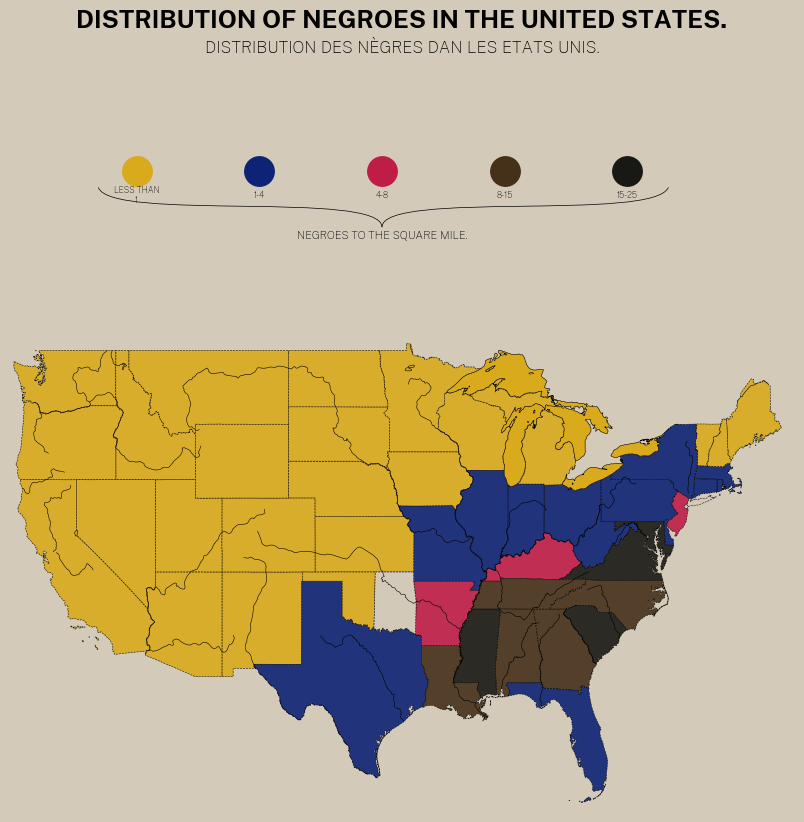

In [22]:
# Create figure
fig, ax = plt.subplots(figsize=(8, 8.5), subplot_kw={"projection": ccrs.PlateCarree()}, facecolor="#d4cab9")

# Set the position of the axes to make the plot area bigger
ax.set_position([0.01, 0.01, 0.98, 0.6])

# Set the geographic extent
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

# Plot state polygons
gdf.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    color=gdf["color"],
    alpha=0.9,
    ec="black",
    ls="dashed",    
    lw=0.4    
)

# Plot clipped rivers
rivers_clipped.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    color="black",
    ls="solid",
    linewidth=0.4
)

# Plot the list of Lakes
lakes_gdf.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    color="#d9aa1c",    
    ec="black",
    linewidth=0.4
)

# Create an inset ax for the legend
inset_ax = fig.add_axes([0.1, 0.7, 0.75, 0.1]) 

# Add left side Brezier curve
patch1 = mpatches.PathPatch(path1, ec="black", fc="none", lw=0.5)
inset_ax.add_patch(patch1)

# Add right side Brezier curve
patch2 = mpatches.PathPatch(path2, ec="black", fc="none", lw=0.5)
inset_ax.add_patch(patch2)

# Set inset axes limits
inset_ax.set_xlim(-0.05, 1.05)
inset_ax.set_ylim(-1.5, 1.7)

# 5 evenly spaced values for the scatters
x = np.linspace(0.05, 0.95, 5)

# Loop through x and color_dict to create legend
for i, (xi, (label, info)) in enumerate(zip(x, color_dict.items())):
    # Scatters
    inset_ax.scatter(xi, 1.1, color=info["color"], s=450)
    
    # Line break for first text item and upper case for the rest
    if i == 0:        
        display_label = "LESS THAN\n1"         
    else:
        display_label = label.upper() 
        
    # Add labels to scatters
    inset_ax.text(xi, 0.2, display_label, fontsize=6, font=font_light, ha="center", va="center")

# Add legend title
inset_ax.text(0.5, -1.4, s="NEGROES TO THE SQUARE MILE.", fontsize=8, font=font_light, ha="center")

# Remove inset ax axis
inset_ax.axis("off")

# Add title and subtitle
fig.text(0.5, 0.95, "DISTRIBUTION OF NEGROES IN THE UNITED STATES.", fontsize=18, font=font_bold, ha="center")
fig.text(0.5, 0.92, "DISTRIBUTION DES NÈGRES DAN LES ETATS UNIS.", fontsize=12, font=font_light, ha="center")

# Remove axis
ax.axis("off")

plt.show()

#plt.savefig("plate38.jpg")

In [23]:
import matplotlib.image as mpimg
from PIL import Image

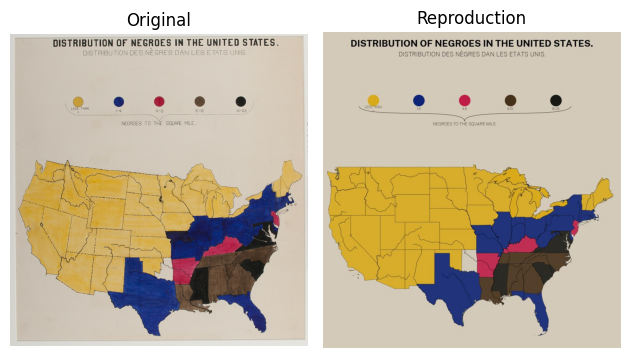

In [24]:
# Load images 
image1 = Image.open("original-plate-38.jpg")
image2 = Image.open("plate38.jpg")

# Convert to numpy arrays
images = [np.array(image1), np.array(image2)]
titles = ["Original", "Reproduction"]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2)

# Loop through axes, images, and titles
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)

# Adjust the layout and show
plt.tight_layout()
plt.show()

# Save the combined figure 
#plt.savefig("plate38sidebyside.png", dpi=300)